In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from collections import Counter

In [9]:
# --- CẤU HÌNH ---
CONFIG = {
    "TRAIN_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\train.csv",
    "TEST_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\test.csv",
    "BASELINE_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\baseline_tfidf_torch.pth",
    "BILSTM_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\best_model.pth",
    "MAX_LEN": 220,
    "MAX_FEATURES": 5000,
    "EMBEDDING_DIM": 512,
    "HIDDEN_DIM": 256,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"
}

CLASSES = ["CLEAN", "OFFENSIVE", "HATE"]

In [10]:
# 1. ĐỊNH NGHĨA LẠI CÁC CLASS MODEL (Giữ nguyên để load weights)
class LogisticRegression_Torch(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression_Torch, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.4):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=2, 
                            bidirectional=True, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hidden, cell) = self.lstm(emb)
        hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        logits = self.fc(self.dropout(hidden_final))
        return logits

class Vocabulary:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx = 2
    def build_vocab(self, texts, min_freq=2):
        counter = Counter()
        for text in texts:
            counter.update(str(text).lower().split())
        for word, count in counter.items():
            if count >= min_freq:
                self.word2idx[word] = self.idx
                self.idx += 1
    def encode(self, text, max_len):
        words = str(text).lower().split()
        indices = [self.word2idx.get(w, 1) for w in words]
        if len(indices) < max_len: indices += [0] * (max_len - len(indices))
        else: indices = indices[:max_len]
        return indices


In [11]:
# 2. HÀM HỖ TRỢ
def load_data(path):
    df = pd.read_csv(path).dropna(subset=['free_text', 'label_id'])
    return df['free_text'].astype(str).tolist(), df['label_id'].astype(int).tolist()

def predict_with_threshold(logits, threshold_hate=0.65, threshold_offensive=0.6):
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    prob_offensive = probs[:, 1]
    prob_hate = probs[:, 2]
    mask_hate = prob_hate > threshold_hate
    preds[mask_hate] = 2
    mask_offensive = (prob_offensive > threshold_offensive) & (~mask_hate)
    preds[mask_offensive] = 1
    return preds

In [12]:
# 3. HÀM ĐÁNH GIÁ (Rút gọn)
def get_predictions_baseline(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=CONFIG["MAX_FEATURES"], ngram_range=(1,2))
    vectorizer.fit(train_texts)
    X_test = vectorizer.transform(test_texts).toarray()
    
    model = LogisticRegression_Torch(CONFIG["MAX_FEATURES"], 3).to(CONFIG["DEVICE"])
    if os.path.exists(CONFIG["BASELINE_PATH"]):
        model.load_state_dict(torch.load(CONFIG["BASELINE_PATH"], map_location=CONFIG["DEVICE"]))
    else:
        print("Không tìm thấy model Baseline!")
        return []
        
    model.eval()
    preds = []
    batch_size = 64
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch_x = torch.tensor(X_test[i:i+batch_size], dtype=torch.float).to(CONFIG["DEVICE"])
            logits = model(batch_x)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    return preds

def get_predictions_bilstm(train_texts, test_texts):
    vocab = Vocabulary()
    vocab.build_vocab(train_texts)
    
    X_test = [torch.tensor(vocab.encode(t, CONFIG["MAX_LEN"])) for t in test_texts]
    X_test = torch.stack(X_test)
    
    model = BiLSTMClassifier(len(vocab.word2idx), CONFIG["EMBEDDING_DIM"], 
                             CONFIG["HIDDEN_DIM"], 3).to(CONFIG["DEVICE"])
    if os.path.exists(CONFIG["BILSTM_PATH"]):
        model.load_state_dict(torch.load(CONFIG["BILSTM_PATH"], map_location=CONFIG["DEVICE"]))
    else:
        print("Không tìm thấy model Bi-LSTM!")
        return []
        
    model.eval()
    preds = []
    batch_size = 32
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch_x = X_test[i:i+batch_size].to(CONFIG["DEVICE"])
            logits = model(batch_x)
            batch_preds = predict_with_threshold(logits, threshold_hate=0.65, threshold_offensive=0.6)
            preds.extend(batch_preds.cpu().numpy())
    return preds


In [ ]:
# 4. MAIN & VISUALIZATION
def main():
    #  LOAD DỮ LIỆU 
    train_texts, _ = load_data(CONFIG["TRAIN_PATH"])
    test_texts, test_labels = load_data(CONFIG["TEST_PATH"])
    
    #  CHẠY DỰ ĐOÁN 
    base_preds = get_predictions_baseline(train_texts, test_texts)
    lstm_preds = get_predictions_bilstm(train_texts, test_texts)
    
    if not base_preds or not lstm_preds:
        return

    # TÍNH METRICS 
    metrics = {
        "Model": ["Baseline (TF-IDF)", "Bi-LSTM"],
        "Accuracy": [accuracy_score(test_labels, base_preds), accuracy_score(test_labels, lstm_preds)],
        "Macro F1": [f1_score(test_labels, base_preds, average='macro'), f1_score(test_labels, lstm_preds, average='macro')],
        "Macro Precision": [precision_score(test_labels, base_preds, average='macro'), precision_score(test_labels, lstm_preds, average='macro')],
        "Macro Recall": [recall_score(test_labels, base_preds, average='macro'), recall_score(test_labels, lstm_preds, average='macro')]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    # --- VẼ BIỂU ĐỒ SO SÁNH ---
    print("\n-> Biểu đồ so sánh chỉ số: ")
    
    # Biểu đồ cột so sánh các chỉ số
    df_melted = df_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
    plt.title("So sánh hiệu năng: Baseline vs Bi-LSTM")
    plt.ylim(0, 1.0)
    plt.legend(loc='lower right')
    
    # Hiển thị giá trị trên cột
    for p in plt.gca().patches:
        if p.get_height() > 0:
            plt.gca().annotate(f"{p.get_height():.3f}", 
                               (p.get_x() + p.get_width() / 2., p.get_height()), 
                               ha = 'center', va = 'center', 
                               xytext = (0, 9), 
                               textcoords = 'offset points')
    plt.show()

    # CONFUSION MATRIX 
    print("\nConfusion Matrix :")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(confusion_matrix(test_labels, base_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=CLASSES, yticklabels=CLASSES)
    axes[0].set_title(f"Baseline (Acc: {metrics['Accuracy'][0]:.3f})")
    
    sns.heatmap(confusion_matrix(test_labels, lstm_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=CLASSES, yticklabels=CLASSES)
    axes[1].set_title(f"Bi-LSTM (Acc: {metrics['Accuracy'][1]:.3f})")
    
    plt.tight_layout()
    plt.show()


-> Biểu đồ so sánh chỉ số: 


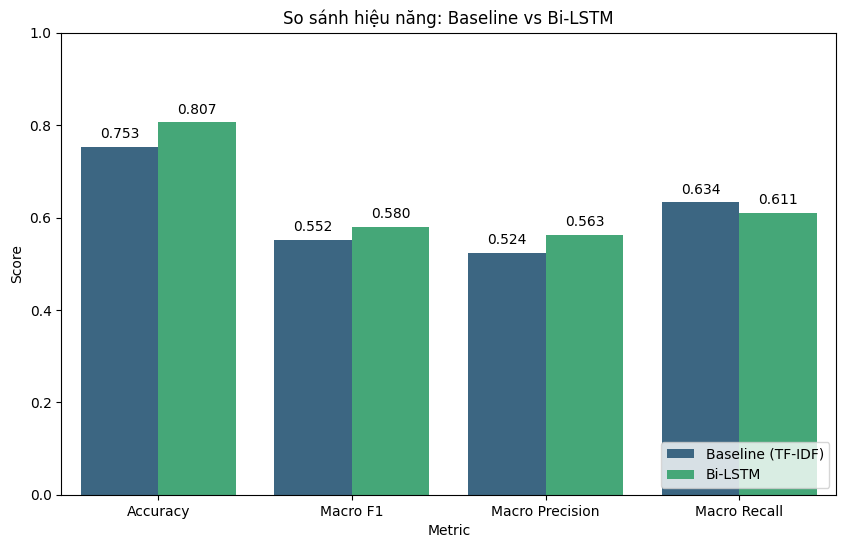


Confusion Matrix :


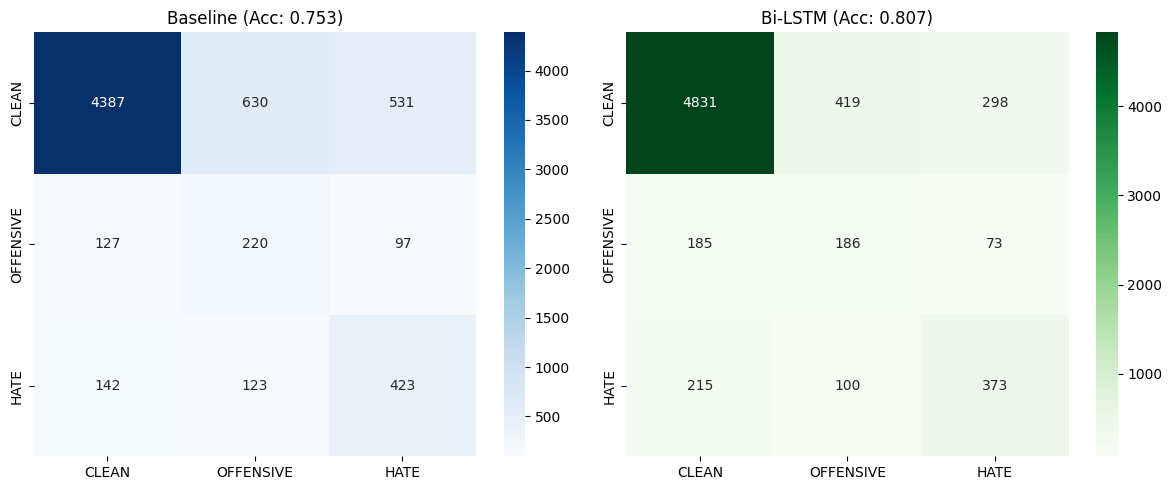

In [16]:
if __name__ == "__main__":
    main()

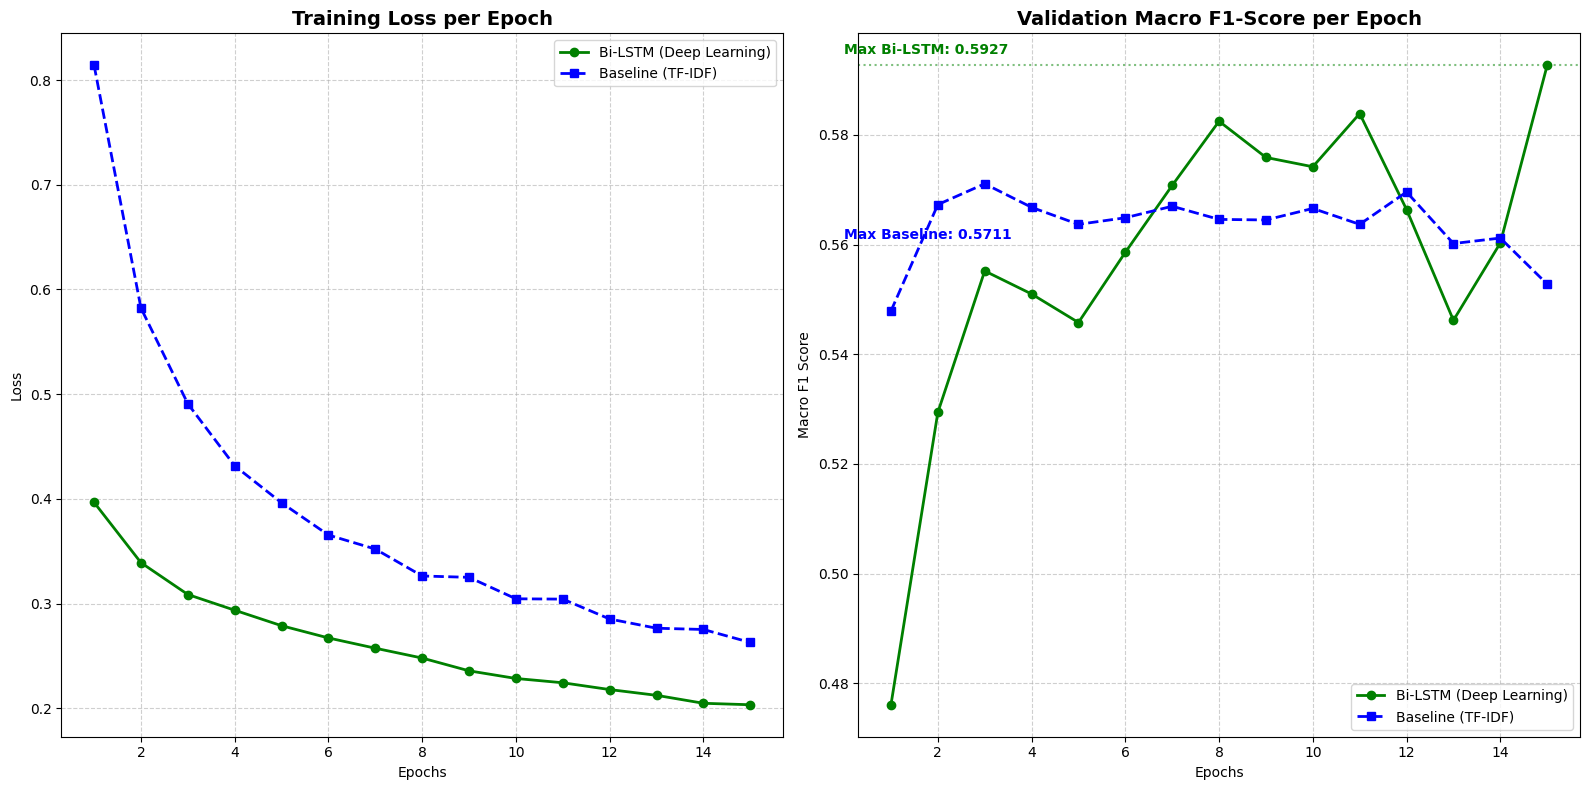

In [20]:
# e lấy từ lịch sử huấn luyện của 2 mô hình
# Dữ liệu Bi-LSTM (20 Epochs - Dừng sớm tại epoch 15)
lstm_epochs = list(range(1, 16))
lstm_loss = [
    0.3966, 0.3390, 0.3086, 0.2936, 0.2788, 
    0.2671, 0.2573, 0.2479, 0.2357, 0.2284, 
    0.2243, 0.2178, 0.2123, 0.2047, 0.2033
]
lstm_f1 = [
    0.4761, 0.5294, 0.5552, 0.5510, 0.5458, 
    0.5586, 0.5708, 0.5825, 0.5759, 0.5742, 
    0.5839, 0.5664, 0.5462, 0.5603, 0.5927
]

# Dữ liệu Baseline (15 Epochs)
base_epochs = list(range(1, 16))
base_loss = [
    0.8141, 0.5822, 0.4908, 0.4315, 0.3962, 
    0.3654, 0.3520, 0.3263, 0.3250, 0.3045, 
    0.3042, 0.2852, 0.2764, 0.2752, 0.2628
]
base_f1 = [
    0.5479, 0.5673, 0.5711, 0.5668, 0.5637, 
    0.5649, 0.5670, 0.5646, 0.5645, 0.5666, 
    0.5637, 0.5696, 0.5602, 0.5612, 0.5528
]

# --- 2. VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(16, 8))

# Biểu đồ 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(lstm_epochs, lstm_loss, 'g-o', label='Bi-LSTM (Deep Learning)', linewidth=2)
plt.plot(base_epochs, base_loss, 'b--s', label='Baseline (TF-IDF)', linewidth=2)
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Validation Macro F1
plt.subplot(1, 2, 2)
plt.plot(lstm_epochs, lstm_f1, 'g-o', label='Bi-LSTM (Deep Learning)', linewidth=2)
plt.plot(base_epochs, base_f1, 'b--s', label='Baseline (TF-IDF)', linewidth=2)

# Đánh dấu điểm cao nhất của mỗi model
max_lstm_f1 = max(lstm_f1)
max_base_f1 = max(base_f1)
plt.axhline(y=max_lstm_f1, color='g', linestyle=':', alpha=0.5)
plt.text(0, max_lstm_f1 + 0.002, f'Max Bi-LSTM: {max_lstm_f1:.4f}', color='green', fontweight='bold')
plt.text(0, max_base_f1 - 0.01, f'Max Baseline: {max_base_f1:.4f}', color='blue', fontweight='bold')

plt.title('Validation Macro F1-Score per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()